# MMM Stress Test #0 — Clean Recovery (Baseline Control)

> **One simple question:** If a correctly specified OLS model is given clean data with known true ROAS, how reliably can it recover the answer?

This notebook uses 156 weeks of synthetic marketing data across 3 channels (Meta, Search, TV) where the true ROAS values are known exactly because we generate the revenue ourselves. The data includes trend, seasonality, and promotions as realistic baseline components, and assumes simple linear media-response (no adstock, no saturation). We repeat this across 500 independent simulations to understand the distribution of OLS estimates under ideal conditions.

**Purpose:** Establish whether OLS is a viable sanity-check model before adding any complexity. This is the reference point against which every subsequent stress test is measured. If OLS cannot recover truth in the clean case, nothing else matters.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

pd.set_option('display.float_format', '{:,.4f}'.format)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

## 1. Configuration

The true ROAS values below are known with certainty because we generate the revenue formula ourselves — there is no measurement error in the ground truth. This is what makes synthetic stress testing so powerful: we know the answer before we fit the model.

The clean case is designed to be favourable to OLS:
- Reasonably strong, independent spend variation (no extreme collinearity)
- Moderate noise relative to media signal
- Correct model specification (OLS includes exactly the controls used to generate the data)

Any failure to recover ROAS in this case would indicate a fundamental problem, not a stress-test failure.

In [2]:
N_WEEKS = 156

TRUE_ROAS = {
    "meta":   2.0,
    "search": 5.0,
    "tv":     1.5,
}

NOISE_SD = 60_000  # GBP — weekly revenue noise standard deviation

print(f"Weeks of data:  {N_WEEKS}")
print(f"True ROAS:      {TRUE_ROAS}")
print(f"Noise SD:       £{NOISE_SD:,}")

Weeks of data:  156
True ROAS:      {'meta': 2.0, 'search': 5.0, 'tv': 1.5}
Noise SD:       £60,000


## 2. Generate synthetic marketing data

Revenue is generated by the following formula:

$$\text{Revenue}_t = \underbrace{2{,}000{,}000 + 4000t + 500{,}000\sin\!\left(\frac{2\pi t}{52}\right) + 150{,}000\cos\!\left(\frac{2\pi t}{52}\right) + 400{,}000 \cdot \text{promo}_t}_{\text{baseline}} + 2.0 \cdot x^{\text{meta}}_t + 5.0 \cdot x^{\text{search}}_t + 1.5 \cdot x^{\text{tv}}_t + \varepsilon_t$$

where $\varepsilon_t \sim \mathcal{N}(0,\, 60{,}000^2)$.

**Baseline components:**
- `2,000,000` — intercept (weekly organic baseline)
- `4000t` — long-run trend
- `sin52 / cos52` — annual seasonality
- `400,000 × promo` — promotional weeks (Bernoulli, 12% probability)

**Spend structure:** Meta and Search are mildly correlated (ρ = 0.20) via a bivariate normal shock. TV is independent. All channels are clipped at a minimum to avoid implausible zero-spend weeks.

In [3]:
def generate_data(rho=0.20, seed=42, n_weeks=N_WEEKS, noise_sd=NOISE_SD):
    """Generate one synthetic dataset with known true ROAS."""
    rng = np.random.default_rng(seed)

    t = np.arange(n_weeks)
    promo = rng.binomial(1, 0.12, size=n_weeks).astype(float)
    sin52 = np.sin(2 * np.pi * t / 52)
    cos52 = np.cos(2 * np.pi * t / 52)

    baseline = (
        2_000_000
        + 4_000 * t
        + 500_000 * sin52
        + 150_000 * cos52
        + 400_000 * promo
    )

    # Correlated Meta / Search spend shocks
    cov = [[1.0, rho], [rho, 1.0]]
    shocks = rng.multivariate_normal([0.0, 0.0], cov, size=n_weeks)

    meta_spend   = np.clip(55_000 + 22_000 * shocks[:, 0], 5_000, None)
    search_spend = np.clip(42_000 + 16_000 * shocks[:, 1], 5_000, None)
    tv_spend     = np.clip(90_000 + 45_000 * rng.standard_normal(size=n_weeks), 0, None)

    noise = rng.normal(0, noise_sd, size=n_weeks)

    revenue = (
        baseline
        + TRUE_ROAS["meta"]   * meta_spend
        + TRUE_ROAS["search"] * search_spend
        + TRUE_ROAS["tv"]     * tv_spend
        + noise
    )

    # True incrementals: ROAS * total spend for each channel
    true_meta_incremental   = TRUE_ROAS["meta"]   * meta_spend.sum()
    true_search_incremental = TRUE_ROAS["search"] * search_spend.sum()
    true_tv_incremental     = TRUE_ROAS["tv"]     * tv_spend.sum()

    df = pd.DataFrame({
        "week":                    t,
        "revenue":                 revenue,
        "baseline":                baseline,
        "meta_spend":              meta_spend,
        "search_spend":            search_spend,
        "tv_spend":                tv_spend,
        "promo":                   promo,
        "trend":                   t.astype(float),
        "sin52":                   sin52,
        "cos52":                   cos52,
        "true_meta_incremental":   true_meta_incremental,
        "true_search_incremental": true_search_incremental,
        "true_tv_incremental":     true_tv_incremental,
    })

    return df

## 3. Inspect one clean dataset

Before running any model, check three things:
1. **True ROAS matches config** — the truth table should show exactly 2.0, 5.0, 1.5
2. **Correlations are low** — clean baseline should have near-zero pairwise spend correlations
3. **Spend has reasonable variation** — coefficient of variation should be substantial (not always-on flat spend)

=== First 5 rows ===
   week        revenue       baseline  meta_spend  search_spend     tv_spend  promo  trend  sin52  cos52  \
0     0 2,646,763.1220 2,150,000.0000 31,317.5001   60,556.7494  76,806.3786 0.0000 0.0000 0.0000 1.0000   
1     1 2,771,620.3580 2,213,174.6712 39,106.1165   50,330.0613 177,175.4023 0.0000 1.0000 0.1205 0.9927   
2     2 2,852,199.8979 2,273,299.1048 79,995.8929   36,197.2555 139,769.7016 0.0000 2.0000 0.2393 0.9709   
3     3 2,763,793.8047 2,329,554.8799 81,537.4883   46,622.4479  46,705.8998 0.0000 3.0000 0.3546 0.9350   
4     4 2,611,810.8612 2,381,179.9899 30,157.2696    7,308.8622 105,646.8804 0.0000 4.0000 0.4647 0.8855   

   true_meta_incremental  true_search_incremental  true_tv_incremental  
0        17,138,467.1348          32,357,305.6569      20,607,674.5231  
1        17,138,467.1348          32,357,305.6569      20,607,674.5231  
2        17,138,467.1348          32,357,305.6569      20,607,674.5231  
3        17,138,467.1348          32,3

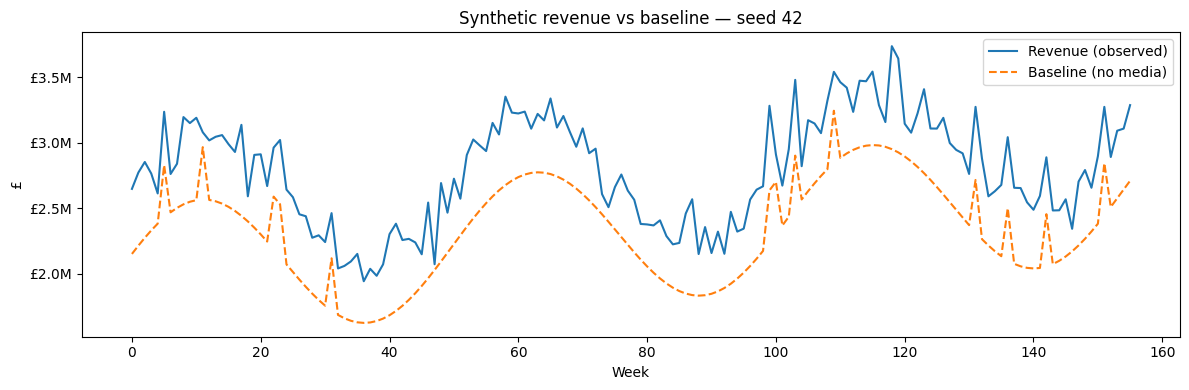

In [4]:
clean_df = generate_data(rho=0.20, seed=42)

print("=== First 5 rows ===")
print(clean_df.head())

print("\n=== Spend correlation matrix ===")
print(clean_df[["meta_spend", "search_spend", "tv_spend"]].corr())

# Truth table
channels = ["meta", "search", "tv"]
truth_rows = []
for ch in channels:
    total_spend = clean_df[f"{ch}_spend"].sum()
    true_inc    = clean_df[f"true_{ch}_incremental"].iloc[0]
    truth_rows.append({
        "channel":                  ch,
        "true_roas":                TRUE_ROAS[ch],
        "total_spend":              total_spend,
        "true_incremental_revenue": true_inc,
        "recovered_true_roas":      true_inc / total_spend,
    })

truth_table = pd.DataFrame(truth_rows).set_index("channel")
print("\n=== Ground truth table ===")
print(truth_table)

# Plot revenue and baseline
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(clean_df["week"], clean_df["revenue"],  label="Revenue (observed)",  lw=1.5)
ax.plot(clean_df["week"], clean_df["baseline"], label="Baseline (no media)",  lw=1.5, ls="--")
ax.set_xlabel("Week")
ax.set_ylabel("£")
ax.set_title("Synthetic revenue vs baseline — seed 42")
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x/1e6:.1f}M'))
plt.tight_layout()
plt.show()

## 4. Fit the simplest possible MMM

We fit an OLS regression with the correct controls — the same variables used to generate the data. This is deliberately the easiest possible case: no model misspecification, no omitted variables, no adstock to estimate.

In this correctly specified linear model, the OLS coefficients on each spend variable are directly interpretable as ROAS estimates. This is a sanity-check model, not a production MMM — but it is the right place to start.

In [5]:
def fit_model(df):
    """Fit a correctly specified OLS MMM. Returns the fitted model."""
    features = ["meta_spend", "search_spend", "tv_spend", "trend", "sin52", "cos52", "promo"]
    X = sm.add_constant(df[features])
    y = df["revenue"]
    model = sm.OLS(y, X).fit()
    return model


model_single = fit_model(clean_df)

print(f"R² = {model_single.rsquared:.4f}")

single_run_rows = []
for ch in ["meta", "search", "tv"]:
    est  = model_single.params[f"{ch}_spend"]
    true = TRUE_ROAS[ch]
    single_run_rows.append({
        "channel":       ch,
        "true_roas":     true,
        "estimated_roas": est,
        "relative_error": (est - true) / true,
    })

single_run_table = pd.DataFrame(single_run_rows).set_index("channel")
print("\n=== Single-run ROAS recovery ===")
print(single_run_table)

R² = 0.9761

=== Single-run ROAS recovery ===
         true_roas  estimated_roas  relative_error
channel                                           
meta        2.0000          1.8756         -0.0622
search      5.0000          5.2184          0.0437
tv          1.5000          1.5988          0.0659


## 5. Do not trust one simulation

A single run tells us almost nothing. The relative error in that one run could be large or small purely by chance — it depends on which particular noise draw we got.

To understand the *distribution* of OLS estimates, we need to repeat the experiment many times with different random seeds (different noise draws, different spend realisations). This is the Monte Carlo approach.

With 500 simulations we can estimate:
- **Bias:** Is the estimator centred on the truth?
- **Variance:** How wide is the spread of estimates?
- **Coverage:** Do 90% confidence intervals contain the truth 90% of the time?
- **Ranking accuracy:** Can the model correctly order the channels by ROAS?

In [6]:
def run_one_simulation(seed, rho=0.20):
    """Run one complete simulation: generate data, fit OLS, extract results."""
    df    = generate_data(rho=rho, seed=seed)
    model = fit_model(df)
    r2    = model.rsquared
    rows  = []
    for ch in ["meta", "search", "tv"]:
        coef_name = f"{ch}_spend"
        est       = model.params[coef_name]
        true      = TRUE_ROAS[ch]
        ci        = model.conf_int(alpha=0.10)  # 90% CI
        ci_low    = ci.loc[coef_name, 0]
        ci_high   = ci.loc[coef_name, 1]
        rows.append({
            "seed":           seed,
            "channel":        ch,
            "true_roas":      true,
            "estimated_roas": est,
            "relative_error": (est - true) / true,
            "ci_low":         ci_low,
            "ci_high":        ci_high,
            "covered_truth":  int(ci_low <= true <= ci_high),
            "r2":             r2,
        })
    return rows

## 6. Clean-case Monte Carlo (500 simulations)

We run 500 independent simulations. Each uses a different seed, which means a different noise draw and different spend realisations — but the same underlying DGP parameters (true ROAS, baseline structure, spend distribution).

We are measuring: given this DGP and this model, what is the full sampling distribution of the ROAS estimator?

In [7]:
N_CLEAN_SIMS = 500
BASE_SEED    = 10_000

all_rows = []
for seed in range(BASE_SEED, BASE_SEED + N_CLEAN_SIMS):
    all_rows.extend(run_one_simulation(seed, rho=0.20))

clean_results = pd.DataFrame(all_rows)

print(f"Monte Carlo complete: {N_CLEAN_SIMS} simulations × 3 channels = {len(clean_results)} rows")
print(clean_results.head(9))

Monte Carlo complete: 500 simulations × 3 channels = 1500 rows
    seed channel  true_roas  estimated_roas  relative_error  ci_low  ci_high  covered_truth     r2
0  10000    meta     2.0000          1.8305         -0.0848  1.4940   2.1670              1 0.9846
1  10000  search     5.0000          5.1561          0.0312  4.6914   5.6208              1 0.9846
2  10000      tv     1.5000          1.5026          0.0018  1.3294   1.6759              1 0.9846
3  10001    meta     2.0000          1.6785         -0.1607  1.3082   2.0489              1 0.9807
4  10001  search     5.0000          4.9902         -0.0020  4.4306   5.5497              1 0.9807
5  10001      tv     1.5000          1.4852         -0.0098  1.2909   1.6796              1 0.9807
6  10002    meta     2.0000          1.8677         -0.0662  1.4918   2.2435              1 0.9781
7  10002  search     5.0000          5.2629          0.0526  4.7295   5.7963              1 0.9781
8  10002      tv     1.5000          1.5883   

## 7. Distribution of ROAS estimates across 500 simulations

The histograms below show where OLS estimates land across 500 different noise draws. The vertical line marks the true ROAS.

Key things to look for:
- **Are estimates centred on the truth?** If the distribution is symmetric around the true ROAS, OLS is unbiased.
- **How wide is the spread?** Narrower = more precise. We expect Meta to be less precise than Search or TV.
- **Why is Meta less precise?** Meta's mean weekly spend is £55k × ROAS 2.0 = £110k incremental revenue. The noise SD is £60k. Signal-to-noise ratio ≈ 1.8. Search's ratio is £42k × 5.0 / £60k ≈ 3.5. Higher SNR means tighter estimates.

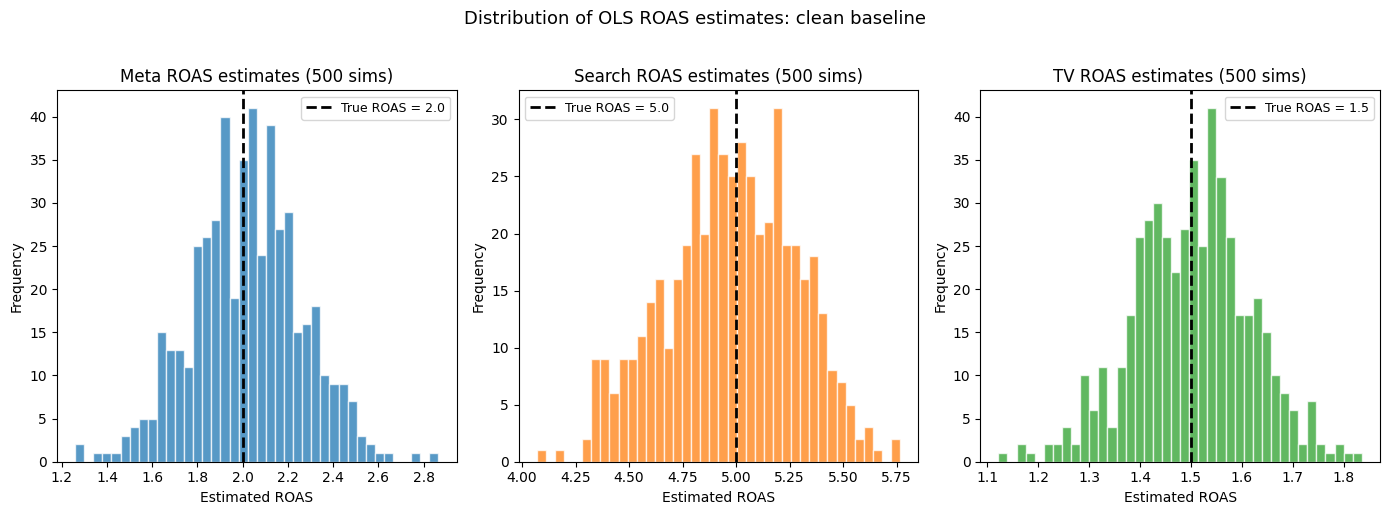

In [14]:
channel_labels = {"meta": "Meta", "search": "Search", "tv": "TV"}
colors         = {"meta": "#1f77b4", "search": "#ff7f0e", "tv": "#2ca02c"}

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, ch in zip(axes, ["meta", "search", "tv"]):
    data = clean_results.loc[clean_results["channel"] == ch, "estimated_roas"]
    ax.hist(data, bins=40, color=colors[ch], alpha=0.75, edgecolor="white")
    ax.axvline(TRUE_ROAS[ch], color="black", lw=2, ls="--", label=f"True ROAS = {TRUE_ROAS[ch]}")
    ax.set_title(f"{channel_labels[ch]} ROAS estimates (500 sims)")
    ax.set_xlabel("Estimated ROAS")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=9)

fig.suptitle("Distribution of OLS ROAS estimates: clean baseline", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 8. Bias vs variance decomposition

**Bias** = the systematic difference between the average estimate and the truth. An unbiased estimator has mean estimate ≈ true ROAS across many simulations.

**Variance** = the spread of estimates across simulations. A high-variance estimator gives very different answers depending on which dataset you happen to observe.

Both matter for practical use. Bias is more dangerous — it means the model is *systematically wrong*, regardless of sample size. High variance means the model is *uncertain*, which is at least honest.

In [9]:
def pct_over_50_error(x):
    return (np.abs(x) > 0.50).mean()

bias_variance_table = (
    clean_results
    .groupby("channel")
    .agg(
        true_roas              =("true_roas",       "first"),
        mean_estimated_roas    =("estimated_roas",  "mean"),
        std_estimated_roas     =("estimated_roas",  "std"),
        median_relative_error_pct=("relative_error", lambda x: np.median(np.abs(x)) * 100),
        prob_over_50pct_error  =("relative_error",  pct_over_50_error),
    )
)

bias_variance_table["bias"] = (
    bias_variance_table["mean_estimated_roas"] - bias_variance_table["true_roas"]
)

print("=== Bias / variance decomposition (500 sims) ===")
print(bias_variance_table)

=== Bias / variance decomposition (500 sims) ===
         true_roas  mean_estimated_roas  std_estimated_roas  median_relative_error_pct  prob_over_50pct_error    bias
channel                                                                                                              
meta        2.0000               2.0207              0.2418                     8.1282                 0.0000  0.0207
search      5.0000               4.9725              0.3034                     4.1277                 0.0000 -0.0275
tv          1.5000               1.5017              0.1147                     5.0984                 0.0000  0.0017


In [ ]:
channels_ordered = ["meta", "search", "tv"]
channel_labels   = {"meta": "Meta", "search": "Search", "tv": "TV"}
colors           = {"meta": "#1f77b4", "search": "#ff7f0e", "tv": "#2ca02c"}

true_vals = [TRUE_ROAS[ch] for ch in channels_ordered]
est_vals  = [bias_variance_table.loc[ch, "mean_estimated_roas"] for ch in channels_ordered]
labels    = [channel_labels[ch] for ch in channels_ordered]

y        = np.arange(len(channels_ordered))
bar_h    = 0.35

fig, ax = plt.subplots(figsize=(9, 4))

bars_true = ax.barh(y + bar_h / 2, true_vals, bar_h,
                    color=[colors[ch] for ch in channels_ordered],
                    alpha=0.4, label="True ROAS", edgecolor="white")
bars_est  = ax.barh(y - bar_h / 2, est_vals, bar_h,
                    color=[colors[ch] for ch in channels_ordered],
                    alpha=0.9, label="Mean estimated ROAS (500 sims)", edgecolor="white")

# Value labels
for bar, val in zip(bars_true, true_vals):
    ax.text(bar.get_width() + 0.04, bar.get_y() + bar.get_height() / 2,
            f"{val:.2f}", va="center", ha="left", fontsize=10, color="dimgray")
for bar, val in zip(bars_est, est_vals):
    ax.text(bar.get_width() + 0.04, bar.get_y() + bar.get_height() / 2,
            f"{val:.2f}", va="center", ha="left", fontsize=10, fontweight="bold")

ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=12)
ax.set_xlabel("ROAS  (£ revenue per £ spend)", fontsize=11)
ax.set_title("True vs Mean Estimated ROAS — clean baseline (500 simulations)", fontsize=12)
ax.legend(fontsize=10)
ax.set_xlim(0, max(true_vals + est_vals) * 1.25)
ax.invert_yaxis()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 9. Confidence interval coverage

A well-calibrated 90% confidence interval should contain the true value in approximately 90% of repeated experiments. This is the frequentist definition of coverage.

If coverage is significantly below 90%, the CIs are too narrow — the model is overconfident. If significantly above 90%, the CIs are too wide — the model is underconfident. In a correctly specified OLS model with valid assumptions, we expect coverage to be close to the nominal level.

In [10]:
coverage_table = (
    clean_results
    .groupby("channel")
    .agg(
        coverage_90pct=("covered_truth", "mean"),
        n_sims        =("seed",          "count"),
    )
)

print("=== 90% CI coverage (target: 0.90) ===")
print(coverage_table)
# Target is 0.90. Values between 0.85 and 0.95 are acceptable for N=500.

=== 90% CI coverage (target: 0.90) ===
         coverage_90pct  n_sims
channel                        
meta             0.8780     500
search           0.9100     500
tv               0.8900     500


## 10. Ranking accuracy

Even if individual ROAS estimates are noisy, a useful model should at least get the *ordering* right. The true ranking is:

$$\text{Search} (5.0) > \text{Meta} (2.0) > \text{TV} (1.5)$$

Ranking accuracy answers the question: "In what fraction of simulations does the model correctly identify Search as the best channel and TV as the weakest?"

This is a practical threshold: even a noisy estimate is useful if it consistently directs budget toward the right channels.

In [11]:
pivot = clean_results.pivot(index="seed", columns="channel", values="estimated_roas")

correct_ranking = (
    (pivot["search"] > pivot["meta"]) &
    (pivot["meta"]   > pivot["tv"])
)

ranking_accuracy = correct_ranking.mean()

print(f"Correct ranking (Search > Meta > TV): {ranking_accuracy:.1%} of simulations")
print(f"Number of simulations: {len(pivot)}")

Correct ranking (Search > Meta > TV): 97.8% of simulations
Number of simulations: 500


## 11. Model fit

In the clean case, the OLS model is correctly specified — it includes exactly the variables used to generate the data. We therefore expect consistently high R². Low R² here would signal a data generation or modelling error.

R² will deteriorate in later stress tests. This clean-case distribution is the benchmark.

R² across 500 simulations:
  Mean:   0.9799
  Min:    0.9711
  Max:    0.9878
  Std:    0.0027


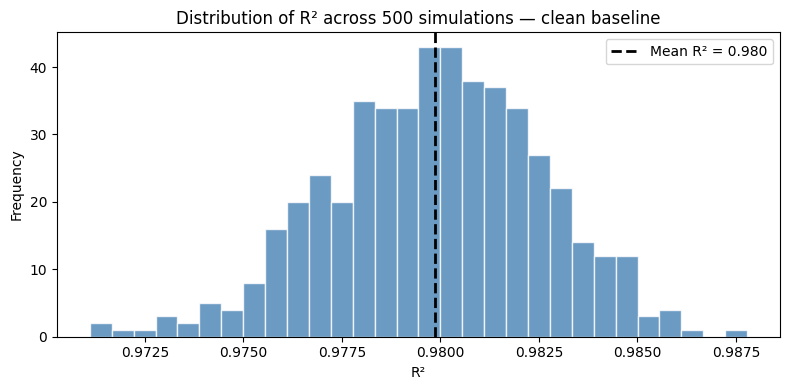

In [12]:
r2_data = clean_results.groupby("seed")["r2"].first()

print(f"R² across {len(r2_data)} simulations:")
print(f"  Mean:   {r2_data.mean():.4f}")
print(f"  Min:    {r2_data.min():.4f}")
print(f"  Max:    {r2_data.max():.4f}")
print(f"  Std:    {r2_data.std():.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(r2_data, bins=30, color="steelblue", alpha=0.8, edgecolor="white")
ax.axvline(r2_data.mean(), color="black", lw=2, ls="--", label=f"Mean R² = {r2_data.mean():.3f}")
ax.set_xlabel("R²")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of R² across 500 simulations — clean baseline")
ax.legend()
plt.tight_layout()
plt.show()

## 12. Save results to CSV

In [13]:
output_path = "mmm_stress_test_00_raw_results.csv"
clean_results.to_csv(output_path, index=False)
print(f"Saved {len(clean_results)} rows to '{output_path}'")
print(f"Columns: {list(clean_results.columns)}")

Saved 1500 rows to 'mmm_stress_test_00_raw_results.csv'
Columns: ['seed', 'channel', 'true_roas', 'estimated_roas', 'relative_error', 'ci_low', 'ci_high', 'covered_truth', 'r2']
